<a href="https://colab.research.google.com/github/Manoj-346/ML/blob/main/Waste_Segregation_Management_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install and import libraries

Run the next two cells first. They install the required packages and import Python libraries.

In [ ]:
!pip install -q tensorflow matplotlib numpy pillow scikit-learn kagglehub

In [ ]:
import os
import json
import shutil
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from google.colab import files
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: False


## Step 2: Download and prepare the dataset

Run the next code cell to automatically download a public Kaggle dataset using KaggleHub.

Recommended dataset used here: **Garbage Classification by Hassnain Zaidi**.

- Total images: about 15,150
- Classes: paper, cardboard, biological waste, metal, plastic, green glass, brown glass, white glass, clothing, shoes, batteries, and general trash
- License shown on Kaggle: CC0 Public Domain

If you use your own dataset instead, arrange it like this:

```text
waste_dataset/
  cardboard/
    image1.jpg
  glass/
    image2.jpg
  metal/
    image3.jpg
  paper/
    image4.jpg
  plastic/
    image5.jpg
  trash/
    image6.jpg
  organic/
    image7.jpg
  e_waste/
    image8.jpg
```

If your dataset has fewer or different class folders, the notebook still works.

Expected output after this step: Colab should print the dataset path and class folders.

In [ ]:
DATA_DIR = Path('/content/drive/MyDrive/Garbage classification')

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def find_image_class_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob('*') if p.is_dir()]
    best = None
    best_count = 0
    for candidate in candidates:
        subdirs = [p for p in candidate.iterdir() if p.is_dir()]
        count = 0
        for subdir in subdirs:
            count += sum(1 for f in subdir.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTS)
        if count > best_count:
            best = candidate
            best_count = count
    if best is None or best_count == 0:
        raise RuntimeError('Could not find image class folders in the dataset.')
    return best

def prepare_dataset_from_folder(source_root):
    class_root = find_image_class_root(source_root)
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    shutil.copytree(class_root, DATA_DIR)
    print('Dataset ready at:', DATA_DIR)
    print('Class folders:', sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()]))

def download_kaggle_dataset():
    import kagglehub
    dataset_path = kagglehub.dataset_download('hassnainzaidi/garbage-classification')
    print('Downloaded Kaggle dataset to:', dataset_path)
    prepare_dataset_from_folder(dataset_path)

# Recommended: run this cell to download and prepare the dataset automatically.
download_kaggle_dataset()

Using Colab cache for faster access to the 'garbage-classification' dataset.
Downloaded Kaggle dataset to: /kaggle/input/garbage-classification
Dataset ready at: /content/drive/MyDrive/Garbage classification
Class folders: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Step 3: Load images for training and validation

Run the next cells to load the dataset into TensorFlow and preview sample images.

Expected output: Colab prints the detected class names and displays sample waste images.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Detected classes:', class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Detected classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


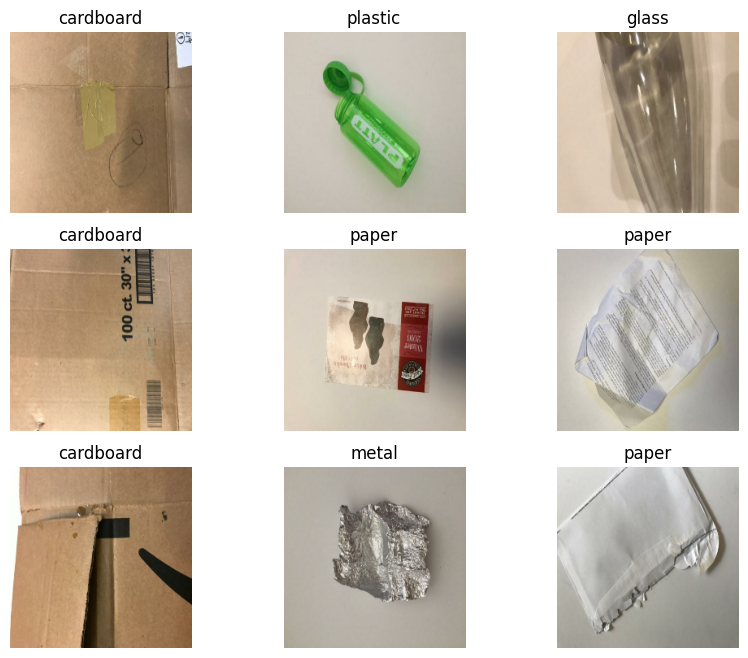

In [ ]:
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

## Step 4: Build the computer vision detector model

This is the main computer vision part of the project.

It uses MobileNetV2 transfer learning. MobileNetV2 already understands useful image features, and we train the final layers for waste classification.

The laptop camera section later will use this same trained model for live detection.

Expected output: Colab shows the model summary.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.12),
    tf.keras.layers.RandomContrast(0.12),
], name='data_augmentation')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='waste_segregation_mobilenetv2')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "waste_segregation_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 5: Train the model

Run the next cell to train the computer vision model on the waste dataset.

Expected output: Colab shows training accuracy and validation accuracy for each epoch.

In [ ]:
EPOCHS = 10

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.5163 - loss: 1.2939 - val_accuracy: 0.6990 - val_loss: 0.7828
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.7354 - loss: 0.7276 - val_accuracy: 0.7683 - val_loss: 0.6375
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.7690 - loss: 0.6150 - val_accuracy: 0.8040 - val_loss: 0.5768
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.8022 - loss: 0.5417 - val_accuracy: 0.8119 - val_loss: 0.5387
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8185 - loss: 0.4943 - val_accuracy: 0.8257 - val_loss: 0.5158
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8343 - loss: 0.4524 - val_accuracy: 0.8198 - val_loss: 0.5219
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.8388 - loss: 0.4337 - val_accuracy: 0.8416 - val_loss: 0.4941
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.8566 - loss: 0.4169 - val_accuracy: 0.8337 - v

## Step 6: Fine-tune for better accuracy

This step unfreezes the top part of MobileNetV2 and trains slowly. It can improve accuracy if you have enough images.

If training takes too long, you may skip this step, but accuracy may be lower.

In [ ]:
base_model.trainable = True

# Keep earlier layers frozen and fine-tune only later layers.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 5
fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.7953 - loss: 0.5741 - val_accuracy: 0.8277 - val_loss: 0.5310
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8892 - loss: 0.3046 - val_accuracy: 0.8554 - val_loss: 0.4596
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.9402 - loss: 0.1861 - val_accuracy: 0.8594 - val_loss: 0.4820
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.9614 - loss: 0.1296 - val_accuracy: 0.8396 - val_loss: 0.5555
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.9777 - loss: 0.0843 - val_accuracy: 0.8455 - val_loss: 0.5545


## Step 7: Evaluate the model

Run the next cells to check model performance.

Expected output: validation accuracy, validation loss, classification report, and confusion matrix.

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f'Validation accuracy: {val_accuracy:.2%}')
print(f'Validation loss: {val_loss:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8594 - loss: 0.4820
Validation accuracy: 85.94%
Validation loss: 0.4820


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

   cardboard       0.96      0.93      0.94        69
       glass       0.98      0.81      0.89       102
       metal       0.69      1.00      0.81        88
       paper       0.91      0.90      0.91       123
     plastic       0.85      0.83      0.84        89
       trash       0.88      0.41      0.56        34

    accuracy                           0.86       505
   macro avg       0.88      0.81      0.83       505
weighted avg       0.88      0.86      0.86       505

Confusion matrix:
[[ 64   0   2   3   0   0]
 [  0  83  10   5   4   0]
 [  0   0  88   0   0   0]
 [  0   0   9 111   1   2]
 [  0   2  12   1  74   0]
 [  3   0   7   2   8  14]]


## Step 8: Save the model and class names

Run this so you can reuse the trained model later without retraining.

In [ ]:
MODEL_PATH = '/content/waste_segregation_model.keras'
CLASS_NAMES_PATH = '/content/class_names.json'

model.save(MODEL_PATH)
with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(class_names, f)

print('Saved model:', MODEL_PATH)
print('Saved class names:', CLASS_NAMES_PATH)

Saved model: /content/waste_segregation_model.keras
Saved class names: /content/class_names.json


## Step 9: Waste segregation message logic

Run this before image upload or camera detection.

The machine learning model predicts the waste type. This helper converts the predicted type into a practical management message.

In [ ]:
SEGREGATION_RULES = {
    'cardboard': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Keep it clean and dry. Flatten it before recycling.'
    },
    'paper': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Recycle only if it is not oily, wet, or food-stained.'
    },
    'plastic': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Rinse if dirty, dry it, and place it in recycling if accepted locally.'
    },
    'metal': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Rinse containers and send them for recycling.'
    },
    'glass': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Handle carefully. Keep broken glass wrapped and separate for safety.'
    },
    'brown_glass': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Handle carefully. Keep broken glass wrapped and separate for safety.'
    },
    'green_glass': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Handle carefully. Keep broken glass wrapped and separate for safety.'
    },
    'white_glass': {
        'bin': 'Dry waste / Recyclable bin',
        'category': 'Dry and recyclable',
        'message': 'Handle carefully. Keep broken glass wrapped and separate for safety.'
    },
    'organic': {
        'bin': 'Wet waste / Compost bin',
        'category': 'Wet biodegradable',
        'message': 'Use composting or dispose in the wet waste bin.'
    },
    'food_waste': {
        'bin': 'Wet waste / Compost bin',
        'category': 'Wet biodegradable',
        'message': 'Use composting or dispose in the wet waste bin.'
    },
    'biological': {
        'bin': 'Wet waste / Compost bin',
        'category': 'Wet biodegradable',
        'message': 'Use composting or dispose in the wet waste bin.'
    },
    'biological_waste': {
        'bin': 'Wet waste / Compost bin',
        'category': 'Wet biodegradable',
        'message': 'Use composting or dispose in the wet waste bin.'
    },
    'e_waste': {
        'bin': 'E-waste collection point',
        'category': 'Hazardous / recyclable through authorized e-waste handling',
        'message': 'Do not mix with normal waste. Send it to an authorized e-waste recycler.'
    },
    'battery': {
        'bin': 'Hazardous waste collection point',
        'category': 'Hazardous',
        'message': 'Do not throw in dry or wet bins. Use a battery collection point.'
    },
    'batteries': {
        'bin': 'Hazardous waste collection point',
        'category': 'Hazardous',
        'message': 'Do not throw in dry or wet bins. Use a battery collection point.'
    },
    'clothing': {
        'bin': 'Textile reuse/recycling or dry waste bin',
        'category': 'Dry reusable/recyclable textile',
        'message': 'Donate if usable. Otherwise send to textile recycling where available.'
    },
    'clothes': {
        'bin': 'Textile reuse/recycling or dry waste bin',
        'category': 'Dry reusable/recyclable textile',
        'message': 'Donate if usable. Otherwise send to textile recycling where available.'
    },
    'shoes': {
        'bin': 'Reuse/recycling or dry waste bin',
        'category': 'Dry reusable/recyclable if accepted locally',
        'message': 'Donate if usable. Otherwise use footwear recycling or dry waste disposal.'
    },
    'trash': {
        'bin': 'General dry waste bin',
        'category': 'Dry non-recyclable',
        'message': 'Dispose in general dry waste if it cannot be reused or recycled.'
    },
    'general_trash': {
        'bin': 'General dry waste bin',
        'category': 'Dry non-recyclable',
        'message': 'Dispose in general dry waste if it cannot be reused or recycled.'
    }
}

def normalize_label(label):
    return label.strip().lower().replace(' ', '_').replace('-', '_')

def get_segregation_message(predicted_class, confidence):
    normalized = normalize_label(predicted_class)
    rule = SEGREGATION_RULES.get(normalized)

    if confidence < 0.55:
        return (
            'The model is not confident enough. Please retake the photo with better lighting, '
            'single waste item focus, and plain background.'
        )

    if rule is None:
        return (
            f'Predicted waste type: {predicted_class}. This class is not in the built-in segregation map. '
            'Add it to SEGREGATION_RULES with its dry/wet/recyclable category.'
        )

    return (
        f'Waste type: {predicted_class}\n'
        f'Category: {rule["category"]}\n'
        f'Put it in: {rule["bin"]}\n'
        f'Action: {rule["message"]}'
    )

# Initialize a log to store prediction results for analytics
import pandas as pd
prediction_log = []

## Step 10: Upload an image and predict waste type

Run this cell if you want to test the model with a saved image.

Expected output: uploaded image preview, predicted waste type, confidence, and dry/wet/recyclable message.

Saving waste.jpg to waste (1).jpg

Analyzing: waste (1).jpg


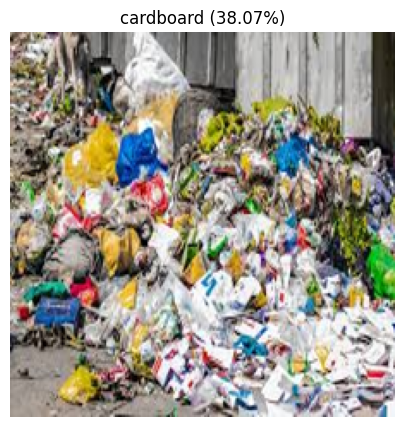

Prediction confidence: 38.07%
The model is not confident enough. Please retake the photo with better lighting, single waste item focus, and plain background.


In [ ]:
def prepare_pil_image(image):
    image = image.convert('RGB')
    display_image = image.resize(IMG_SIZE)
    image_array = tf.keras.utils.img_to_array(display_image)
    image_array = np.expand_dims(image_array, axis=0)
    return display_image, image_array

def predict_waste_from_pil(image, show_image=True, source='unknown'):
    display_image, model_input = prepare_pil_image(image)
    probabilities = model.predict(model_input, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_class = class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    # Log the prediction
    prediction_log.append({
        'timestamp': pd.Timestamp.now(),
        'predicted_class': predicted_class,
        'confidence': confidence,
        'source': source
    })

    if show_image:
        plt.figure(figsize=(5, 5))
        plt.imshow(display_image)
        plt.axis('off')
        plt.title(f'{predicted_class} ({confidence:.2%})')
        plt.show()

    print('Prediction confidence:', f'{confidence:.2%}')
    print(get_segregation_message(predicted_class, confidence))
    return predicted_class, confidence

def predict_waste_image(image_path):
    image = Image.open(image_path)
    return predict_waste_from_pil(image, show_image=True, source='uploaded_image')

uploaded = files.upload()
for filename in uploaded.keys():
    print('\nAnalyzing:', filename)
    predict_waste_image(filename)

## Step 11: Laptop camera + computer vision detector

Run this in Google Colab after training the model.

This section opens your laptop camera in the browser, captures what you show to the camera, and sends the captured frame to the trained computer vision model.

Colab may ask for camera permission. Allow it.

Expected output: camera opens, one frame is captured, and the model prints the waste category message.

<IPython.core.display.Javascript object>

Camera is ready. Hold the waste item clearly in front of the camera.


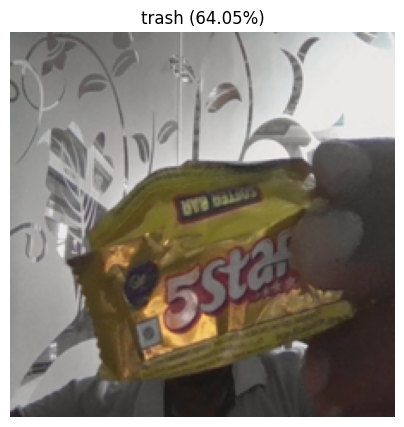

Prediction confidence: 64.05%
Waste type: trash
Category: Dry non-recyclable
Put it in: General dry waste bin
Action: Dispose in general dry waste if it cannot be reused or recycled.


('trash', 0.6404728293418884)

In [ ]:
from IPython.display import Javascript, clear_output, display
from google.colab.output import eval_js
from base64 import b64decode
import io
import time

def setup_camera():
    display(Javascript('''
    window.wasteCamera = window.wasteCamera || {};

    window.wasteCamera.start = async function() {
      if (window.wasteCamera.video) {
        return true;
      }

      const div = document.createElement('div');
      div.style.border = '2px solid #2f855a';
      div.style.padding = '10px';
      div.style.width = 'fit-content';
      div.style.background = '#f0fff4';

      const label = document.createElement('div');
      label.textContent = 'Show one waste item clearly in front of the camera';
      label.style.fontWeight = 'bold';
      label.style.marginBottom = '8px';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.width = '420px';
      video.setAttribute('playsinline', '');

      div.appendChild(label);
      div.appendChild(video);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      window.wasteCamera.video = video;
      window.wasteCamera.stream = stream;
      return true;
    };

    window.wasteCamera.capture = async function() {
      await window.wasteCamera.start();
      const video = window.wasteCamera.video;
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      return canvas.toDataURL('image/jpeg', 0.85);
    };

    window.wasteCamera.stop = function() {
      if (window.wasteCamera.stream) {
        window.wasteCamera.stream.getTracks().forEach(track => track.stop());
      }
      window.wasteCamera.video = null;
      window.wasteCamera.stream = null;
      return true;
    };
    '''))
    eval_js('window.wasteCamera.start()')

def capture_camera_image():
    data_url = eval_js('window.wasteCamera.capture()')
    image_bytes = b64decode(data_url.split(',')[1])
    return Image.open(io.BytesIO(image_bytes)).convert('RGB')

def predict_from_camera_once():
    setup_camera()
    print('Camera is ready. Hold the waste item clearly in front of the camera.')
    time.sleep(2)
    image = capture_camera_image()
    return predict_waste_from_pil(image, show_image=True, source='camera_once')

predict_from_camera_once()